In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# Load BTC and SPY
btc_raw = yf.download("BTC-USD", start="2018-01-01",
                       end="2024-01-01", auto_adjust=True)
spy_raw = yf.download("SPY",     start="2018-01-01",
                       end="2024-01-01", auto_adjust=True)

btc_raw.columns = btc_raw.columns.get_level_values(0)
spy_raw.columns = spy_raw.columns.get_level_values(0)

btc = btc_raw["Close"].squeeze()
spy = spy_raw["Close"].squeeze()

# Returns — BTC uses 365 days, SPY uses 252
btc_ret = np.log(btc / btc.shift(1)).dropna()
spy_ret = np.log(spy / spy.shift(1)).dropna()

btc_vol = btc_ret.std() * np.sqrt(365)
spy_vol = spy_ret.std() * np.sqrt(252)

print(f"{'='*50}")
print(f"  BTC vs SPY STATISTICAL COMPARISON")
print(f"{'='*50}")
print(f"  {'Metric':<20} {'BTC':>12} {'SPY':>12}")
print(f"  {'-'*45}")
print(f"  {'Ann. Volatility':<20} {btc_vol:>12.2%} {spy_vol:>12.2%}")
print(f"  {'Vol ratio':<20} {btc_vol/spy_vol:>12.1f}x {'1.0x':>12}")
print(f"  {'Max 1-day loss':<20} {btc_ret.min():>12.2%} {spy_ret.min():>12.2%}")
print(f"  {'Max 1-day gain':<20} {btc_ret.max():>12.2%} {spy_ret.max():>12.2%}")
print(f"  {'Skewness':<20} {btc_ret.skew():>12.3f} {spy_ret.skew():>12.3f}")
print(f"  {'Kurtosis':<20} {btc_ret.kurtosis():>12.3f} {spy_ret.kurtosis():>12.3f}")
print(f"{'='*50}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

  BTC vs SPY STATISTICAL COMPARISON
  Metric                        BTC          SPY
  ---------------------------------------------
  Ann. Volatility            70.34%       20.47%
  Vol ratio                     3.4x         1.0x
  Max 1-day loss            -46.47%      -11.59%
  Max 1-day gain             17.18%        8.67%
  Skewness                   -1.056       -0.784
  Kurtosis                   14.285       11.929


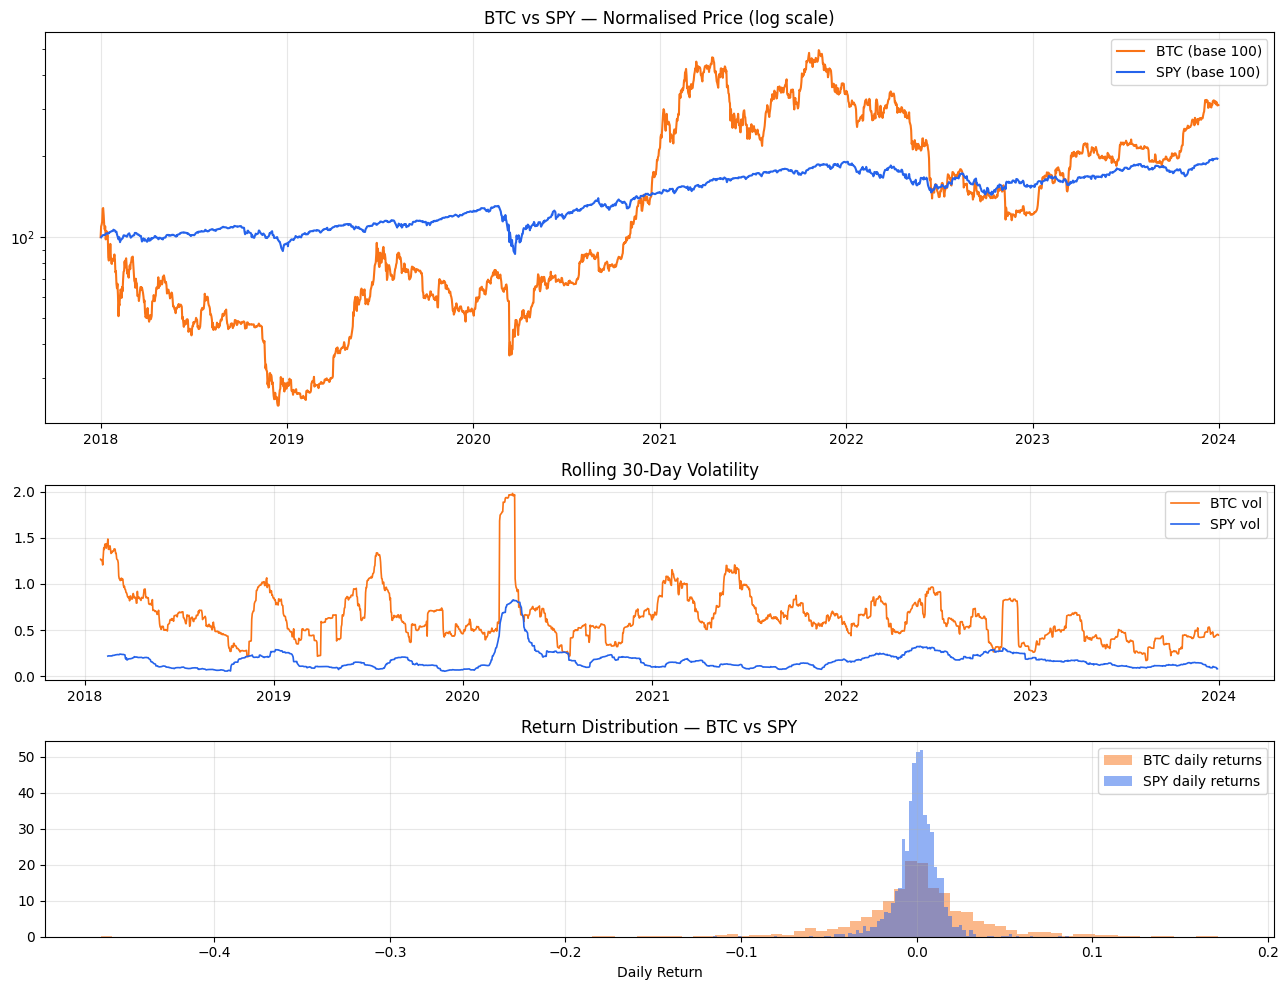

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10),
    gridspec_kw={'height_ratios': [2, 1, 1]})

# Panel 1: Normalised price
btc_norm = btc / btc.iloc[0] * 100
spy_norm = spy / spy.iloc[0] * 100
ax1.plot(btc_norm, color='#f97316', lw=1.5, label='BTC (base 100)')
ax1.plot(spy_norm, color='#2563eb', lw=1.5, label='SPY (base 100)')
ax1.set_yscale('log')
ax1.set_title('BTC vs SPY — Normalised Price (log scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Rolling 30-day volatility
btc_rvol = btc_ret.rolling(30).std() * np.sqrt(365)
spy_rvol = spy_ret.rolling(30).std() * np.sqrt(252)
ax2.plot(btc_rvol, color='#f97316', lw=1.2, label='BTC vol')
ax2.plot(spy_rvol, color='#2563eb', lw=1.2, label='SPY vol')
ax2.set_title('Rolling 30-Day Volatility')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Return distribution comparison
ax3.hist(btc_ret, bins=100, alpha=0.5,
         color='#f97316', label='BTC daily returns',
         density=True)
ax3.hist(spy_ret, bins=100, alpha=0.5,
         color='#2563eb', label='SPY daily returns',
         density=True)
ax3.set_title('Return Distribution — BTC vs SPY')
ax3.set_xlabel('Daily Return')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# SMA 50/200 strategy on BTC
sma50  = btc.rolling(50).mean()
sma200 = btc.rolling(200).mean()

position = (sma50 > sma200).astype(int).shift(1).fillna(0)
position = position.reindex(btc_ret.index).fillna(0)
trades   = position.diff().abs().fillna(0)

# Higher costs for crypto — wider spreads
btc_sma_ret = position * btc_ret - trades * 0.001

# Vol targeting on BTC — essential given extreme volatility
target_vol  = 0.20  # 20% target — higher than SPY's 10%
realized_vol = btc_ret.rolling(20).std() * np.sqrt(365)
vol_scalar   = (target_vol / realized_vol).clip(0, 1)
btc_vt_ret   = position * btc_ret * vol_scalar.shift(1) - trades * 0.001

# Buy and hold BTC
bh_ret = btc_ret.copy()

def perf(r, name, days=365):
    ar = r.mean() * days
    av = r.std()  * np.sqrt(days)
    sh = (ar - 0.02) / av if av > 0 else 0
    w  = (1 + r).cumprod()
    dd = ((w - w.cummax()) / w.cummax()).min()
    print(f"  {name:<25} {ar:>8.2%} {av:>8.2%} {sh:>7.2f} {dd:>9.2%}")

print(f"\n{'='*65}")
print(f"  BTC STRATEGY COMPARISON (2018-2024)")
print(f"{'='*65}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*60}")
perf(btc_sma_ret, "BTC SMA 50/200")
perf(btc_vt_ret,  "BTC SMA + VolTgt")
perf(bh_ret,      "BTC Buy & Hold")
print(f"{'='*65}")

# Compare to SPY
print(f"\n  For reference:")
perf(spy_ret.reindex(btc_ret.index).fillna(0),
     "SPY Buy & Hold", days=252)


  BTC STRATEGY COMPARISON (2018-2024)
  Strategy                   Ann Ret  Ann Vol  Sharpe    Max DD
  ------------------------------------------------------------
  BTC SMA 50/200              28.53%   49.93%    0.53   -72.55%
  BTC SMA + VolTgt             7.82%   17.75%    0.33   -38.06%
  BTC Buy & Hold              18.83%   70.34%    0.24   -86.65%

  For reference:
  SPY Buy & Hold               7.72%   16.99%    0.34   -35.75%



  FUNDING RATE FILTER RESULTS
  BTC SMA+VolTgt+Funding:
    Ann Return : 4.24%
    Ann Vol    : 16.69%
    Sharpe     : 0.13
    Max DD     : -39.95%


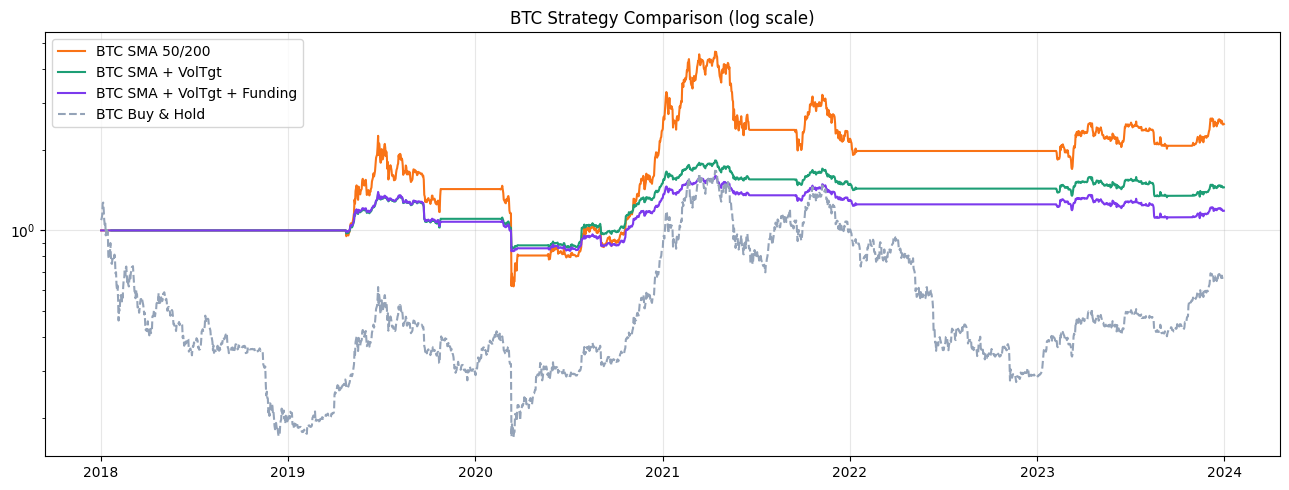

In [5]:
# Simulate funding rates
# Real funding data would come from exchange APIs
# We simulate based on market conditions
np.random.seed(42)

# Funding rate correlated with momentum and vol
momentum_30d = btc_ret.rolling(30).mean() * 365
vol_30d      = btc_ret.rolling(30).std() * np.sqrt(365)

# Simulate 8-hourly funding rate
# High when market is up a lot and leveraged
funding_daily = (
    0.0003 * (momentum_30d / vol_30d).clip(-3, 3) +
    np.random.normal(0, 0.0002, len(btc_ret))
)
funding = pd.Series(funding_daily.values,
                     index=btc_ret.index)

# Funding rate signal
# Extreme positive funding = overcrowded longs = fade
funding_ma   = funding.rolling(7).mean()
funding_std  = funding.rolling(30).std()
funding_z    = (funding - funding_ma) / funding_std

# Reduce position when funding is extreme
funding_scalar = pd.Series(1.0, index=btc_ret.index)
funding_scalar[funding_z > 2] = 0.0   # flat when extreme
funding_scalar[funding_z > 1] = 0.5   # half when elevated

# Apply funding filter to best strategy
btc_funded_ret = (position *
                  funding_scalar.reindex(btc_ret.index).fillna(1) *
                  btc_ret * vol_scalar.shift(1).fillna(1) -
                  trades * 0.001)

ar = btc_funded_ret.mean() * 365
av = btc_funded_ret.std()  * np.sqrt(365)
sh = (ar - 0.02) / av
w  = (1 + btc_funded_ret).cumprod()
dd = ((w - w.cummax()) / w.cummax()).min()

print(f"\n{'='*55}")
print(f"  FUNDING RATE FILTER RESULTS")
print(f"{'='*55}")
print(f"  BTC SMA+VolTgt+Funding:")
print(f"    Ann Return : {ar:.2%}")
print(f"    Ann Vol    : {av:.2%}")
print(f"    Sharpe     : {sh:.2f}")
print(f"    Max DD     : {dd:.2%}")
print(f"{'='*55}")

# Plot equity curves
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot((1+btc_sma_ret).cumprod(),    color='#f97316',
        lw=1.5, label='BTC SMA 50/200')
ax.plot((1+btc_vt_ret).cumprod(),     color='#1D9E75',
        lw=1.5, label='BTC SMA + VolTgt')
ax.plot((1+btc_funded_ret).cumprod(), color='#7c3aed',
        lw=1.5, label='BTC SMA + VolTgt + Funding')
ax.plot((1+bh_ret).cumprod(),         color='#94a3b8',
        lw=1.5, linestyle='--', label='BTC Buy & Hold')
ax.set_yscale('log')
ax.set_title('BTC Strategy Comparison (log scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
